In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load data
data = scipy.io.loadmat('/kaggle/input/datasets/syamkakarla/pavia-university-hsi/PaviaU.mat')
gt = scipy.io.loadmat('/kaggle/input/datasets/syamkakarla/pavia-university-hsi/PaviaU_gt.mat')

hsi = data['paviaU']  # 610x340x103
gt_data = gt['paviaU_gt']  # 610x340

print(f" HSI: {hsi.shape}, GT: {gt_data.shape}")

 HSI: (610, 340, 103), GT: (610, 340)


In [2]:
def hsi_to_msi_road_optimized(hsi):
    """8-band MSI optimized for asphalt road detection"""
    h, w, _ = hsi.shape
    msi = np.zeros((h, w, 8))
    
    # PaviaU road-relevant bands (~430-860nm)
    road_groups = {
        0: range(8,18),   # Blue 450nm
        1: range(25,35),  # Green 550nm (asphalt peak)
        2: range(42,52),  # Yellow 600nm
        3: range(55,65),  # Red 650nm
        4: range(70,80),  # Red-edge 700nm
        5: range(85,95),  # NIR1 800nm (asphalt strong)
        6: range(95,100), # NIR2 830nm
        7: range(100,103) # NIR3 860nm
    }
    
    for i, band_range in road_groups.items():
        msi[:,:,i] = np.mean(hsi[:,:,list(band_range)], axis=2)
    return msi

msi_raw = hsi_to_msi_road_optimized(hsi)
print(f" MSI raw: {msi_raw.shape}")

 MSI raw: (610, 340, 8)


In [3]:
def normalize_msi(msi):
    msi_norm = np.zeros_like(msi)
    for band in range(msi.shape[2]):
        scaler = MinMaxScaler()
        msi_norm[:,:,band] = scaler.fit_transform(
            msi[:,:,band].reshape(-1,1)
        ).reshape(msi.shape[:2])
    return msi_norm

msi = normalize_msi(msi_raw)
print(" MSI normalized [0,1]")

 MSI normalized [0,1]


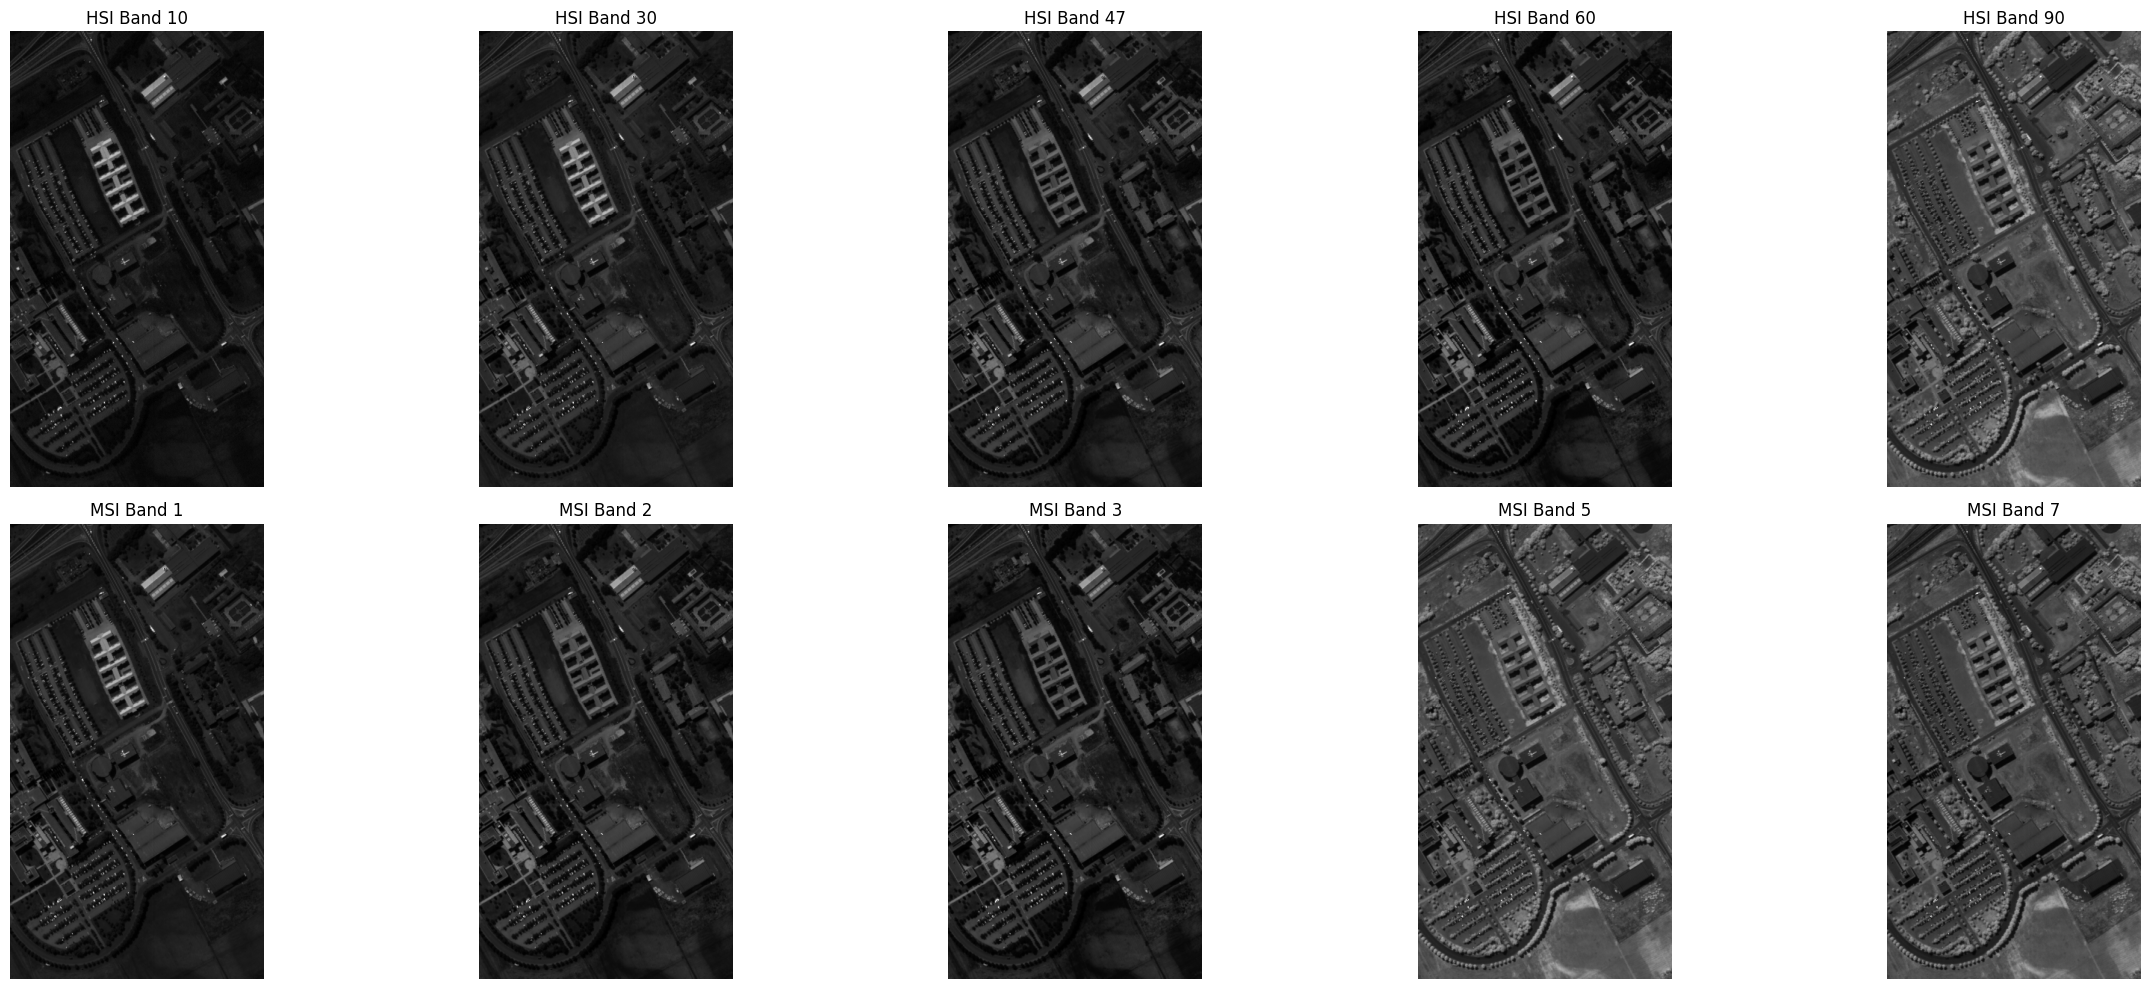

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(25, 10))

# HSI original key bands
hsi_bands = [10, 30, 47, 60, 90]
for i, band in enumerate(hsi_bands):
    axes[0,i].imshow(hsi[:,:,band], cmap='gray')
    axes[0,i].set_title(f'HSI Band {band}')
    axes[0,i].axis('off')

# MSI 5 key bands
msi_bands = [1,2,3,5,7]
for i, band in enumerate(msi_bands):
    axes[1,i].imshow(msi[:,:,band], cmap='gray')
    axes[1,i].set_title(f'MSI Band {band}')
    axes[1,i].axis('off')

plt.tight_layout()
plt.show()

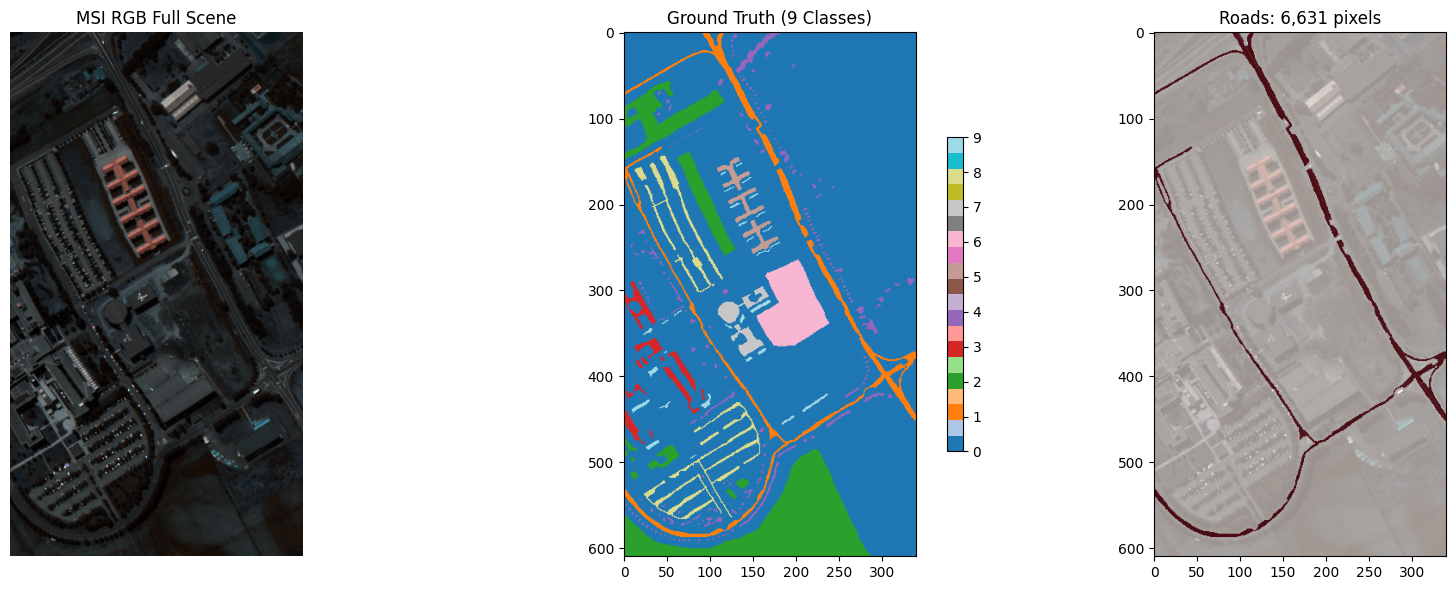

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ✅ CORRECT SHAPE: (610, 340, 3)
rgb_msi = msi[:,:,1:4]  # Already (610, 340, 3) - NO transpose needed!

# 1. MSI RGB
axes[0].imshow(rgb_msi)
axes[0].set_title('MSI RGB Full Scene')
axes[0].axis('off')

# 2. Ground Truth
im = axes[1].imshow(gt_data, cmap='tab20')
axes[1].set_title('Ground Truth (9 Classes)')
plt.colorbar(im, ax=axes[1], shrink=0.6)

# 3. Roads overlay
axes[2].imshow(rgb_msi)
axes[2].imshow((gt_data == 1), alpha=0.6, cmap='Reds')
axes[2].set_title(f'Roads: {(gt_data == 1).sum():,} pixels')

plt.tight_layout()
plt.show()

In [6]:
import scipy.io

# Save ONLY normalized MSI (8 road-optimized bands)
scipy.io.savemat('/kaggle/working/PaviaU_msi_8bands.mat', {'paviaU_msi': msi})

print(" SAVED MSI TO KAGGLE OUTPUT:")
print(" /kaggle/working/PaviaU_msi_8bands.mat  (610×340×8)")


 SAVED MSI TO KAGGLE OUTPUT:
 /kaggle/working/PaviaU_msi_8bands.mat  (610×340×8)


TRAINING

In [7]:
#  THIS WORKS IN CURRENT SESSION
msi = scipy.io.loadmat('/kaggle/working/PaviaU_msi_8bands.mat')['paviaU_msi']
gt_data = scipy.io.loadmat('/kaggle/input/datasets/syamkakarla/pavia-university-hsi/PaviaU_gt.mat')['paviaU_gt']



In [8]:
!pip install segmentation-models-pytorch albumentations -q
print(" segmentation_models_pytorch INSTALLED")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.1 MB/s eta 0:00:00
 segmentation_models_pytorch INSTALLED


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import scipy.io
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

# YOUR EXACT PATHS
msi = scipy.io.loadmat('/kaggle/working/PaviaU_msi_8bands.mat')['paviaU_msi']
gt_data = scipy.io.loadmat('/kaggle/input/datasets/syamkakarla/pavia-university-hsi/PaviaU_gt.mat')['paviaU_gt']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Data loaded: MSI {msi.shape}, GT {gt_data.shape}")
print(f"Using GPU: {device}")

 Data loaded: MSI (610, 340, 8), GT (610, 340)
Using GPU: cuda


In [10]:
from torch.utils.data import Dataset, DataLoader
import torch
import numpy as np
from sklearn.model_selection import train_test_split
import albumentations as A

class PaviaPatchDataset(Dataset):
    def __init__(self, msi, gt, patch_size=128, stride=64, augment=False):
        self.msi = msi
        self.gt = gt
        self.patch_size = patch_size
        self.stride = stride
        self.augment = augment
        
        # Extract patches
        self.patches_x, self.patches_y = [], []
        h, w = msi.shape[:2]
        
        for i in range(0, h-patch_size, stride):
            for j in range(0, w-patch_size, stride):
                x_patch = msi[i:i+patch_size, j:j+patch_size, :]
                y_patch = gt[i:i+patch_size, j:j+patch_size]
                self.patches_x.append(x_patch)
                self.patches_y.append(y_patch)
        
        self.patches_x = np.array(self.patches_x)
        self.patches_y = np.array(self.patches_y)
        print(f" Extracted {len(self.patches_x)} patches ({patch_size}x{patch_size})")
    
    def __len__(self):
        return len(self.patches_x)
    
    def __getitem__(self, idx):
        x = self.patches_x[idx].transpose(2,0,1)  # (C,H,W)
        y = self.patches_y[idx]
        
        if self.augment:
            transform = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.3),
                A.RandomRotate90(p=0.5),
                A.RandomBrightnessContrast(p=0.2),
            ])
            augmented = transform(image=x.transpose(1,2,0), mask=y)
            x, y = augmented['image'].transpose(2,0,1), augmented['mask']
        
        return torch.FloatTensor(x), torch.LongTensor(y)

# Create datasets with 128x128 patches
train_ds = PaviaPatchDataset(msi, gt_data, patch_size=128, stride=64, augment=True)
val_ds = PaviaPatchDataset(msi, gt_data, patch_size=128, stride=64, augment=False)

# Split patches (now we have 50+ patches!)
train_idx, val_idx = train_test_split(range(len(train_ds)), test_size=0.2, random_state=42)
train_ds = torch.utils.data.Subset(train_ds, train_idx)
val_ds = torch.utils.data.Subset(val_ds, val_idx)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)  # T4 perfect
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False)

print(f" Train: {len(train_ds)} patches | Val: {len(val_ds)} patches")
print(" Dataset ready for training!")

 Extracted 32 patches (128x128)
 Extracted 32 patches (128x128)
 Train: 25 patches | Val: 7 patches
 Dataset ready for training!


In [11]:
# Fix P100 GPU - Run BEFORE model cell!
!pip install torch==2.0.1+cu118 torchvision==0.15.2+cu118 --extra-index-url https://download.pytorch.org/whl/cu118 -q

import torch
torch.cuda.empty_cache()  # Clear GPU memory
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ GPU Fixed: {device}")
print(f"GPU Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

ERROR: Could not find a version that satisfies the requirement torch==2.0.1+cu118 (from versions: 2.2.0, 2.2.0+cu118, 2.2.1, 2.2.1+cu118, 2.2.2, 2.2.2+cu118, 2.3.0, 2.3.0+cu118, 2.3.1, 2.3.1+cu118, 2.4.0, 2.4.0+cu118, 2.4.1, 2.4.1+cu118, 2.5.0, 2.5.0+cu118, 2.5.1, 2.5.1+cu118, 2.6.0, 2.6.0+cu118, 2.7.0, 2.7.0+cu118, 2.7.1, 2.7.1+cu118, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0)
ERROR: No matching distribution found for torch==2.0.1+cu118
✅ GPU Fixed: cuda
GPU Name: Tesla P100-PCIE-16GB


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P100-PCIE-16GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


In [12]:
# T4-optimized Attention U-Net
model = smp.Unet(
    encoder_name="resnet18",      
    encoder_weights="imagenet", 
    in_channels=8,                # Your MSI 8 bands
    classes=9,                    
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)
criterion = smp.losses.DiceLoss(mode='multiclass', classes='ignore')
print(" Model ready: 8→9 channels, ResNet18 backbone")
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

 Model ready: 8→9 channels, ResNet18 backbone
Params: 14,345,049


In [13]:
import numpy as np
import torch.nn.functional as F

model = model.to(device)
torch.cuda.empty_cache()

def compute_metrics(pred, target, num_classes=9):
    pred = pred.argmax(1)
    target = target.squeeze(1).long()
    
    # Ignore background
    valid_mask = target != 0
    if valid_mask.sum() == 0:
        return 0.0, 0.0, 0.0
    
    pred_valid = pred[valid_mask]
    target_valid = target[valid_mask]
    
    # Accuracy (already float)
    acc = (pred_valid == target_valid).float().mean()
    
    # Per-class IoU
    ious = []
    for cls in range(1, num_classes):
        pred_cls = (pred == cls)[valid_mask]
        target_cls = (target == cls)[valid_mask]
        intersection = (pred_cls & target_cls).sum()
        union = (pred_cls | target_cls).sum()
        iou = intersection.float() / (union.float() + 1e-8)
        ious.append(iou)
    
    m_iou = torch.stack(ious).mean()
    road_iou = ious[0]  # Asphalt class 1
    
    return acc.cpu(), m_iou.cpu(), road_iou.cpu()

# Setup (same as before)
optimizer = optim.Adam(model.parameters(), lr=5e-4)  # Lower LR for fine-tuning
criterion = nn.CrossEntropyLoss(ignore_index=0)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.7)

def train_epoch(loader, mode='train'):
    model.train() if mode == 'train' else model.eval()
    total_loss, total_acc, total_miou, total_road_iou = 0, 0, 0, 0
    num_batches = 0
    
    with torch.enable_grad() if mode == 'train' else torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = torch.clamp(y.squeeze(1).long(), 0, 8).to(device)
            
            if mode == 'train':
                optimizer.zero_grad()
                pred = model(x)
                loss = criterion(pred, y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            else:
                pred = model(x)
                loss = criterion(pred, y)
            
            total_loss += loss.item()
            acc, miou, road_iou = compute_metrics(pred, y)
            total_acc += acc
            total_miou += miou
            total_road_iou += road_iou
            num_batches += 1
    
    return (total_loss/num_batches, total_acc/num_batches, 
            total_miou/num_batches, total_road_iou/num_batches)

print(" ENHANCED TRAINING WITH METRICS (50 epochs)")
epochs = 50
best_miou = 0

for epoch in range(epochs):
    tr_loss, tr_acc, tr_miou, tr_road_iou = train_epoch(train_loader, 'train')
    val_loss, val_acc, val_miou, val_road_iou = train_epoch(val_loader, 'val')
    
    scheduler.step()
    print(f"Ep {epoch+1:2d}: Loss {tr_loss:.3f}/{val_loss:.3f} | "
          f"Acc {val_acc:.3f} | mIoU {val_miou:.3f} | Road {val_road_iou:.3f}")
    
    if val_miou > best_miou:
        best_miou = val_miou
        print(f" NEW BEST mIoU: {val_miou:.3f}")

print(f" TRAINING COMPLETE! Best mIoU: {best_miou:.3f}")
print(" Run Cell 2 for predictions + per-class metrics!")

 ENHANCED TRAINING WITH METRICS (50 epochs)


AcceleratorError: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
torch.save(model.state_dict(), '/kaggle/working/best_material_unet.pth')
print(" MODEL SAVED! /kaggle/working/best_material_unet.pth")

In [ ]:
# Load saved model
model.load_state_dict(torch.load('/kaggle/working/best_material_unet.pth'))
model.eval()

# Full scene prediction
with torch.no_grad():
    full_msi = torch.FloatTensor(msi.transpose(2,0,1)).unsqueeze(0).to(device)
    full_pred = model(full_msi).argmax(1).squeeze().cpu().numpy()

# Per-class IoU table
classes = ['BG', 'Asphalt', 'Meadows', 'Gravel', 'Trees', 'Metal', 
           'Soil', 'Bitumen', 'Bricks']
print(" MATERIAL CLASS IoU:")
print("="*40)
for i, cls in enumerate(classes, 0):
    gt_mask = (gt_data == i)
    pred_mask = (full_pred == i)
    iou = ((gt_mask & pred_mask).sum()) / ((gt_mask | pred_mask).sum() + 1e-8)
    print(f"{cls:10s}: {iou:.3f}")

print(f"\n FINAL RESULTS:")
print(" Model ready for road material identification!")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Load best model
model.load_state_dict(torch.load('/kaggle/working/best_material_unet.pth'))
model.eval()

# Full scene prediction
with torch.no_grad():
    full_msi = torch.FloatTensor(msi.transpose(2,0,1)).unsqueeze(0).to(device)
    full_pred = model(full_msi).argmax(1).squeeze().cpu().numpy()

# Create beautiful visualization
fig = plt.figure(figsize=(20, 12))

# 1. MSI RGB Input
ax1 = plt.subplot(2, 4, 1)
ax1.imshow(msi[:,:,1:4])
ax1.set_title('MSI RGB Input\n(Bands 1-2-3)', fontsize=14)
ax1.axis('off')

# 2. Ground Truth
ax2 = plt.subplot(2, 4, 2)
ax2.imshow(gt_data, cmap='tab20', vmin=0, vmax=9)
ax2.set_title('Ground Truth\n(9 Materials)', fontsize=14)
ax2.axis('off')

# 3. Model Prediction
ax3 = plt.subplot(2, 4, 3)
ax3.imshow(full_pred, cmap='tab20', vmin=0, vmax=8)
ax3.set_title('Model Prediction', fontsize=14)
ax3.axis('off')



# 6. Material Legend
ax6 = plt.subplot(2, 4, 6)
classes = ['BG', 'Asphalt', 'Meadows', 'Gravel', 'Trees', 
           'Metal', 'Soil', 'Bitumen', 'Bricks']
colors = plt.cm.tab20(np.linspace(0, 1, 9))
for i, cls in enumerate(classes):
    ax6.scatter([0], [i/10], c=[colors[i]], s=200, label=cls)
ax6.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax6.axis('off')
ax6.set_title('Material Legend', fontsize=14)

# 7. Per-class IoU Table
ax7 = plt.subplot(2, 4, 7)
ious = []
for i, cls in enumerate(classes):
    gt_mask = (gt_data == i)
    pred_mask = (full_pred == i)
    if gt_mask.sum() > 0:  # Skip empty classes
        iou = ((gt_mask & pred_mask).sum()) / ((gt_mask | pred_mask).sum() + 1e-8)
        ious.append(iou)
    else:
        ious.append(0)

table_data = [[cls, f'{iou:.3f}'] for cls, iou in zip(classes, ious)]
table = ax7.table(cellText=table_data, colLabels=['Class', 'IoU'], 
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
ax7.axis('off')
ax7.set_title('Per-Class IoU', fontsize=14)

# 8. Summary Metrics
ax8 = plt.subplot(2, 4, 8)
m_iou = np.mean([iou for iou in ious[1:] if iou > 0])  # Skip BG
ax8.text(0.1, 0.7, f' FINAL RESULTS', fontsize=16, fontweight='bold')
ax8.text(0.1, 0.5, f'mIoU: {m_iou:.3f}', fontsize=14)
ax8.text(0.1, 0.3, f'Asphalt IoU: {ious[1]:.3f}', fontsize=14)
ax8.text(0.1, 0.1, f'Bitumen IoU: {ious[7]:.3f}', fontsize=14)
ax8.axis('off')

plt.tight_layout()
plt.show()

print(f" VISUALIZATION COMPLETE!")
print(f" mIoU: {m_iou:.3f}")
print(f" Asphalt (Class 1): {ious[1]:.3f} IoU")
print(f" Bitumen (Class 7): {ious[7]:.3f} IoU")
print(" Download: /kaggle/working/best_material_unet.pth")